# Proyecto Base - Evaluación de Minería de Datos

## Información del Grupo

- **Nombre o Número de Grupo:** los narutos
- **Sección:** 003D
- **Fecha de Entrega:** 9/5/2026

---

## Integrantes del Grupo (máximo 3 estudiantes)

### Estudiante 1
- **Nombre:** Jesús
- **Apellido:** Márquez
- **Correo institucional:** jesu.marquez@duocuc.cl

### Estudiante 2
- **Nombre:** Mariana
- **Apellido:** Ramírez
- **Correo institucional:** maria.ramirezc@duocuc.cl


---

## Tema del Proyecto
Análisis y predicción del éxito comercial cinematográfico basado en métricas de producción y atributos textuales.

El objetivo es identificar cómo variables cuantitativas (presupuesto, popularidad, duración) y la identidad textual de una obra (título y eslogan) influyen en la recaudación de una película, desarrollando un modelo de regresión que estime los ingresos financieros.

---

## Descripción del Proyecto
La industria del cine implica inversiones masivas con un alto grado de incertidumbre. Este proyecto busca entender si es posible predecir el retorno económico de una película utilizando sus datos duros de producción y su identidad visual mínima (título y tagline).

---

## Introducción a la Metodología

Este documento sigue la estructura de la metodología **CRISP-DM** (*Cross Industry Standard Process for Data Mining*), utilizada ampliamente para abordar proyectos de ciencia de datos y machine learning. Se compone de seis fases fundamentales:

---

## Fases de CRISP-DM

### 1. Comprensión del Negocio
Describa el objetivo del proyecto desde una perspectiva práctica o social. ¿Qué decisión se espera mejorar gracias al modelo?

---

### 2. Comprensión de los Datos
- Describa la fuente del dataset
- Número de registros y columnas
- Variables objetivo y predictoras
- Tipos de datos: numéricos, categóricos, fechas, etc.

---

### 3. Preparación de los Datos

#### a. Limpieza de Datos
- Eliminación o imputación de valores nulos
- Corrección de errores y outliers
- Revisión de duplicados

#### b. Transformaciones y Encoding
- Normalización, estandarización, escalamiento si aplica
- Codificación de variables categóricas (OneHotEncoding, LabelEncoder)
- Selección o ingeniería de características (feature selection/engineering)

---

### 4. Análisis Exploratorio de Datos
- Estadísticas descriptivas
- Visualizaciones significativas: histogramas, boxplots, gráficos de dispersión, mapas de calor, etc.
- Hipótesis o tendencias observadas

---

### 5. Modelado y Justificación

#### a. Tipo de problema
- ¿Se trata de clasificación o regresión?

#### b. Modelo(s) utilizados
- Algoritmo seleccionado (Regresión lineal, árbol de decisión, SVM, etc.)
- Justificación teórica y empírica del modelo
- Parámetros utilizados (si aplica)

---

### 6. Evaluación del Modelo
- División entrenamiento/prueba o validación cruzada
- Métricas reportadas:
  - Clasificación: Accuracy, Precision, Recall, F1-score
  - Regresión: RMSE, MAE, R²
- Análisis de errores y limitaciones

---

### 7. Conclusiones y Recomendaciones
- Interpretación de los resultados del modelo
- Limitaciones del análisis
- Propuestas de mejora o posibles extensiones del proyecto
- Aplicabilidad en un contexto real

---

## Recomendaciones Finales

- Documente cada etapa con claridad, justificando sus decisiones con fundamentos teóricos o exploratorios.
- Use visualizaciones para apoyar sus conclusiones.
- Acompañe su informe con código limpio y bien comentado.
- Recuerde que el proceso analítico y reflexivo es más valioso que lograr "el mejor modelo".

---


## 1. Comprensión del Negocio
El objetivo es predecir la recaudación de una película (revenue) usando datos de producción. Queremos saber si el presupuesto y la identidad de la película (su nombre y eslogan) son suficientes para estimar su éxito financiero y reducir riesgos en la industria del cine.

## 2. Comprensión de los Datos
Usamos el dataset movies.csv.

Trabajaremos con

Variable a predecir: revenue.

Variables explicativas: budget, popularity, runtime, vote_count, title y tagline.
Se eliminaron las categorías (géneros, actores) para medir el impacto directo de la inversión y la marca.

## 3. Preparación de los Datos
En esta etapa importamos las librerías necesarias para el análisis numérico, la visualización y el modelado. También cargamos el dataset original movies.csv.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Instalación de librería para encoding de alta cardinalidad
!pip install category_encoders
import category_encoders as ce

df = pd.read_csv('/content/movies.csv')

#### 3.1 Depuración de Datos
Se aplicó una eliminación completa de registros nulos y se filtraron los valores en cero de budget y revenue para asegurar la calidad de los datos.
Se eliminaron todas las columnas categóricas excepto title y tagline.

In [4]:
# 1. Eliminación total de nulos y valores en cero
df_clean = df.dropna().copy()
df_clean = df_clean[(df_clean['budget'] > 0) & (df_clean['revenue'] > 0)]

# 2. Selección de variables
columnas_interes = ['budget', 'popularity', 'runtime', 'vote_count', 'title', 'tagline', 'revenue']
df_final = df_clean[columnas_interes]

#### 3.2 Encoding (si aplica)
Se utilizó Binary Encoding para los textos. Dado que el título y el eslogan son únicos (alta cardinalidad), esta técnica permite transformarlos en bits numéricos compactos sin crear miles de columnas como haría el One-Hot Encoding.

In [5]:
# 3. Binary Encoding para Title y Tagline
encoder = ce.BinaryEncoder(cols=['title', 'tagline'])
df_encoded = encoder.fit_transform(df_final)

print(f"Dataset listo con {len(df_encoded)} registros.")

Dataset listo con 1230 registros.


## 4. Análisis Exploratorio
Analizamos la correlación entre las variables para entender qué factores están más ligados al éxito económico.Analizamos la correlación entre las variables para entender qué factores están más ligados al éxito económico.

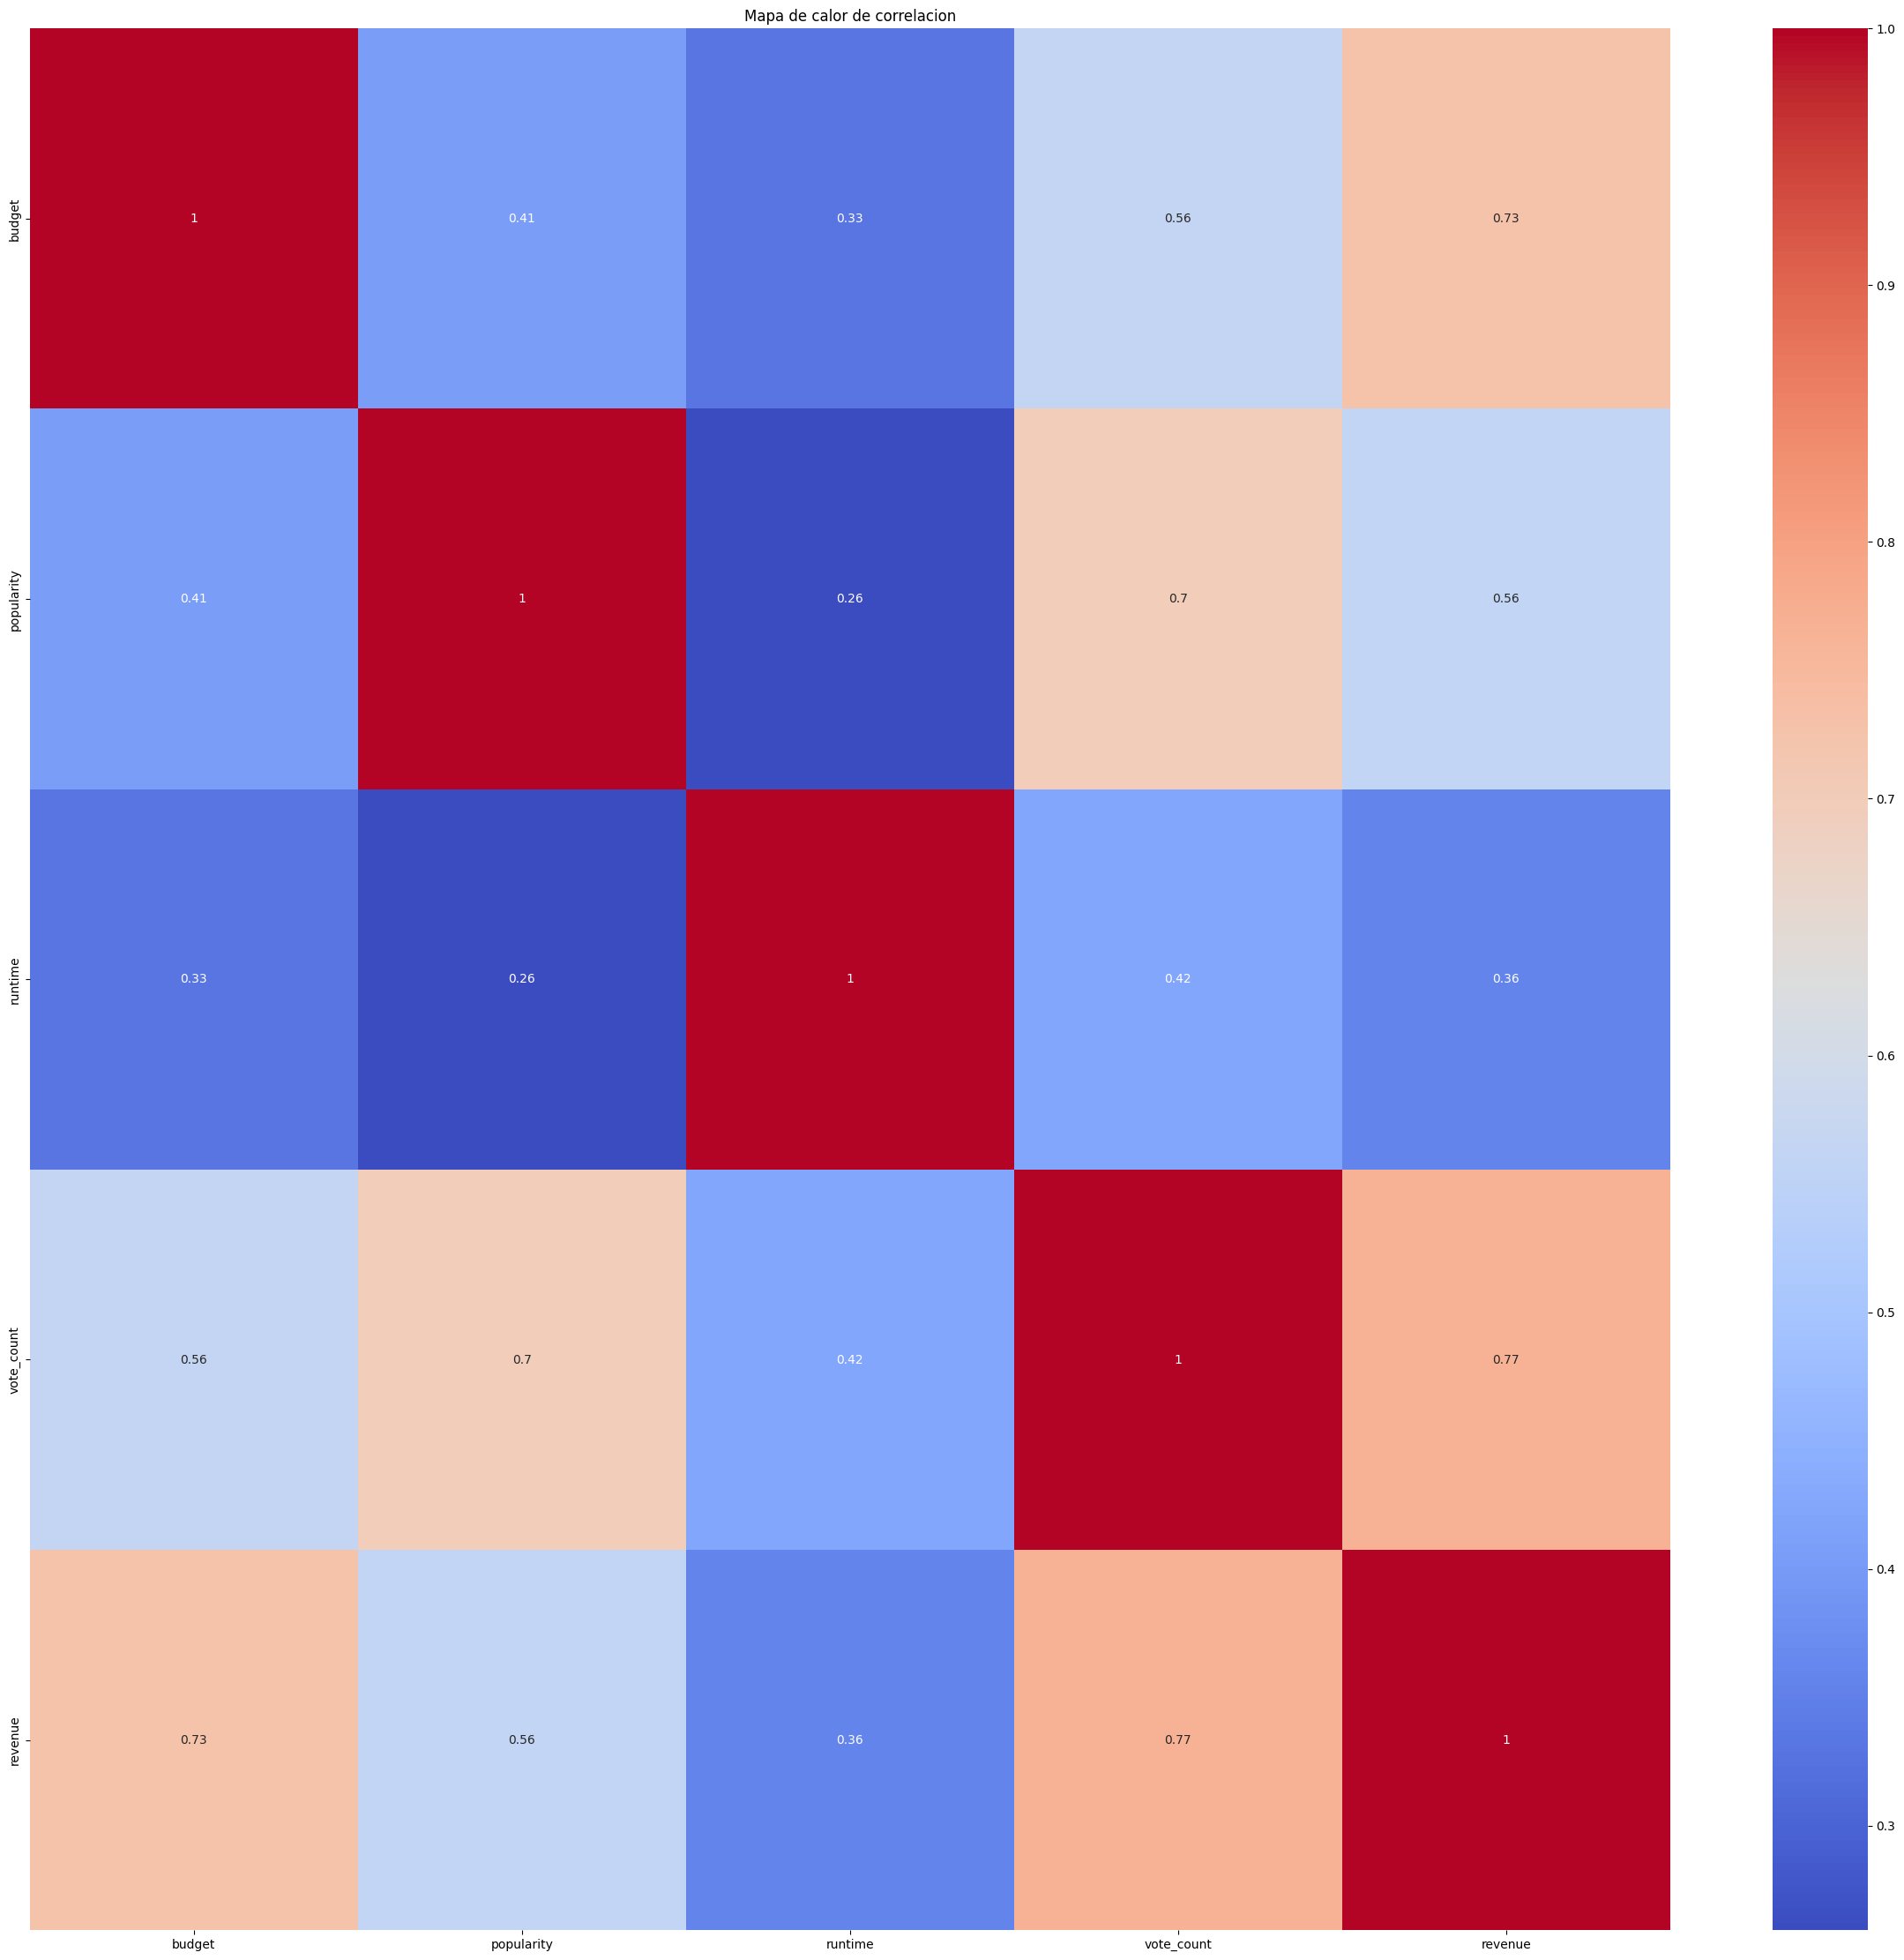

In [8]:
# Mapa de calor de correlaciones
corr = df_final.select_dtypes(include='number').corr() #correlacion

plt.figure(figsize=(30,28))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Mapa de calor de correlacion")
plt.show()

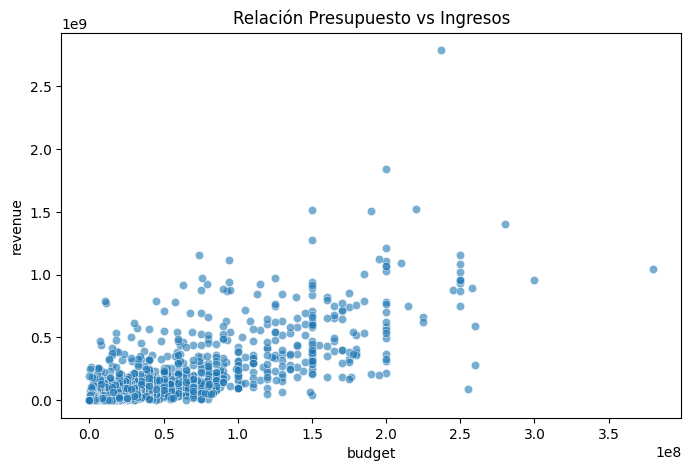

In [9]:

# Visualización Presupuesto vs Ingresos
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_final, x='budget', y='revenue', alpha=0.6)
plt.title("Relación Presupuesto vs Ingresos")
plt.show()

## 5. Modelado
Se define un problema de Regresión Lineal Múltiple, utilizando las variables de producción y los bits generados por el Binary Encoding para predecir la variable objetivo revenue.

In [10]:
# Definición de X e y
X = df_encoded.drop('revenue', axis=1)
y = df_encoded['revenue']

# División entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento del modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

## 6. Entrenamiento y Evaluación
Evaluamos el desempeño mediante el coeficiente R² (porcentaje de varianza explicada) y el MAE (error promedio en dólares).


R² Score: -0.1024
MAE: $92,846,767.80


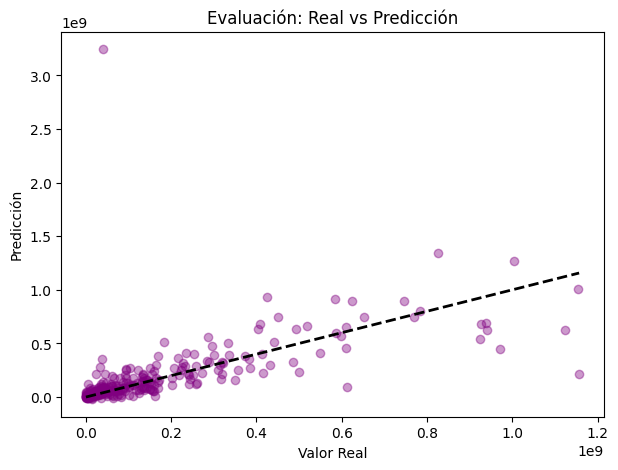

In [11]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"MAE: ${mae:,.2f}")

# Gráfico de Real vs Predicción
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, color='purple', alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Valor Real")
plt.ylabel("Predicción")
plt.title("Evaluación: Real vs Predicción")
plt.show()

## 8. Conclusiones
El modelo permite observar cómo el presupuesto y la popularidad son los motores principales del ingreso.

Al eliminar los nulos y las categorías de género, el modelo es más robusto pero pierde contexto temático.
Esta herramienta es funcional para estimaciones rápidas de ingresos basadas en la inversión inicial y la identidad del título.